### **Python code for analysis of Wallmart data globally - Phase 2**

**Walmart Sales Analysis: Phase 2 - To predict walmart sales or any other metric for each quarter in future for year 2017 to 2025 using machine learning and deep learning algorithms, we follow the below mentioned steps**
1. Prepare the Dataset
2. Load the dataset
3. **Analyse the prediction requirement of the client** and check which features are required for prediction process using AI models and select those features from the dataset and if new columns or features has to be generated then perform the Feature engineering process
4. **Feature Engineering** - Generate a Quarter column based on the Order Date column
5. **Data Splitting process** - Extract relevant features such as year, quarter, and any other useful columns required for prediction
6. Split the dataset records - only for the selected features i.e quarter and quarterly sales features into training and testing sets required for testing and training the AI models
7. Train and evaluate the Machine Learning(ML)-algorithms like regression models (e.g., Linear Regression, Random Forest, XGBoost) & Deep Learning(DL) algorithms like Neural Networks
8. **Predict quarter sales for the future i.e for 2017 t0 2025** - Using the machine learning models
9. **Visualize the predictions** for the specified quarters through Visualization
10. **Visualize and analyze the trends and predictions for each quarter for the clients requirement**
11. **Select the Best fit AI Model in this process using MSE Factor and r2_score factor**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       Row ID                  Order ID Order Date  Ship Date       Ship Mode  \
0       40098  CA-2014-AB10015140-41954 2014-11-11 2014-11-13     First Class   
1       26341    IN-2014-JR162107-41675 2014-02-05 2014-02-07    Second Class   
2       25330    IN-2014-CR127307-41929 2014-10-17 2014-10-18     First Class   
3       13524   ES-2014-KM1637548-41667 2014-01-28 2014-01-30     First Class   
4       47221   SG-2014-RH9495111-41948 2014-11-05 2014-11-06        Same Day   
...       ...                       ...        ...        ...             ...   
51285   29002   IN-2015-KE1642066-42174 2015-06-19 2015-06-19        Same Day   
51286   34337  US-2014-ZD21925140-41765 2014-05-06 2014-05-10  Standard Class   
51287   31315  CA-2012-ZD21925140-41147 2012-08-26 2012-08-31    Second Class   
51288    9596   MX-2013-RB1979518-41322 2013-02-17 2013-02-21

/tmp/ipython-input-10691514.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sr = pd.Series(pd.date_range('2012-12-12 12:12', periods=5, freq='H'))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
   Quarter         Sales  Quarter_Num
0   2012Q1  3.383628e+05         8049
1   2012Q2  4.801328e+05         8050
2   2012Q3  6.110859e+05         8051
3   2012Q4  8.298693e+05         8052
4   2013Q1  3.993677e+05         8053
5   2013Q2  6.255929e+05         8054
6   2013Q3  7.377689e+05         8055
7   2013Q4  9.147092e+05         8056
8   2014Q1  5.650196e+05         8057
9   2014Q2  8.348395e+05         8058
10  2014Q3  9.330370e+05         8059
11  2014Q4  1.072850e+06         8060
12  2015Q1  6.892067e+05         8061
13  2015Q2  9.329870e+05         8062
14  2015Q3  1.196483e+06         8063
15  2015Q4  1.481189e+06         8064
    Quarter_Num
0          8069
1          8070
2          8071
3          8072
4          8073
5          8074
6          8075
7          8076
8          8077
9          8078
10         8079
11         8080
12         8081
13         8082
14         8083
15         8084
16  

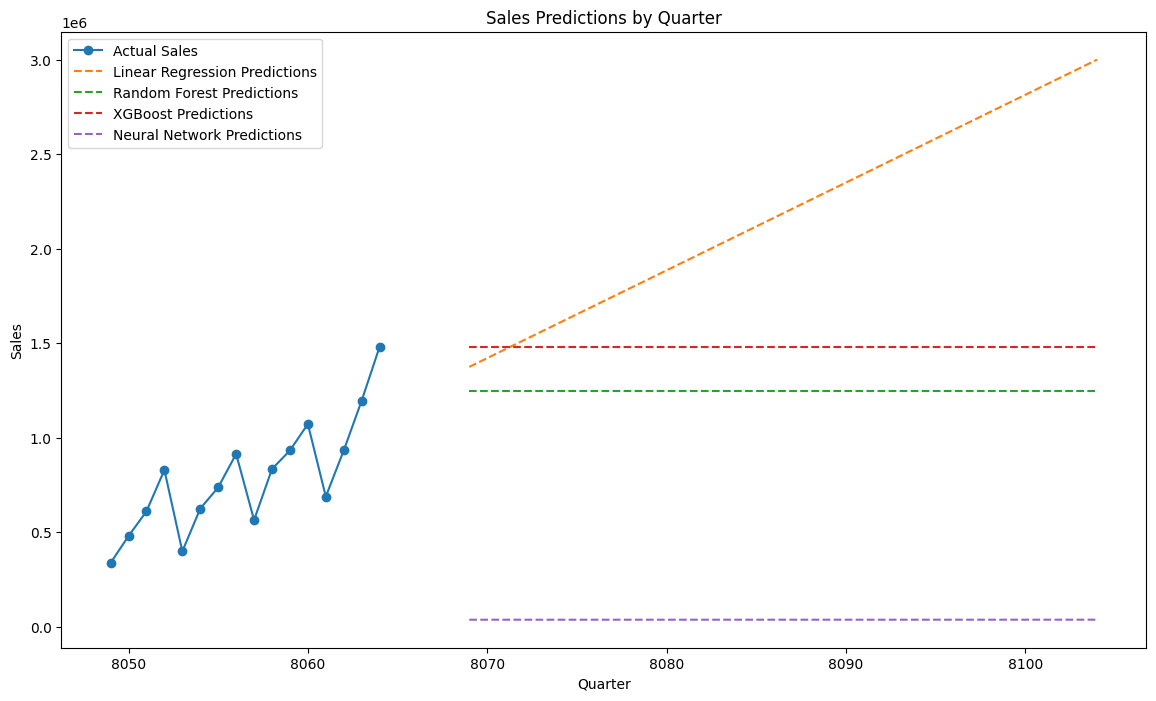

Linear Regression - MSE: 6178933480.674593 , R2: 0.9418179948874718
Random Forest - MSE: 39019260079.93952 , R2: 0.6325872747200609
XGBoost - MSE: 53033661162.65129 , R2: 0.5006250262198009
Neural Network - MSE: 493669412437.3058 , R2: -3.6484844622716857


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from google.colab import drive



# Load the filepath for the dataset - Please update this path to your Excel file
file_path = '/content/drive/MyDrive/DA_Docs/DA-Docs/DA-session Docs/Data_walmart project-Docs/Walmart Global Superstore_Dataset.xlsx'


# Load the data (adjust the sheet name if needed)
data = pd.read_excel(file_path, engine='openpyxl')
#data = pd.read_excel('Walmart_superstore_2016.xlsx')
print (data)

# Convert Order Date to datetime
print(data['Order Date'])
data['Order Date'] = pd.to_datetime(data['Order Date'])
print(data['Order Date'])


# Examples for series data & datetime object
df = pd.DataFrame({'date_str': ['2023-01-15', '2023-02-28', '2023-03-10']})
print(df)
df['date'] = pd.to_datetime(df['date_str'])
print(df['date'])

# Creating the Series
sr = pd.Series(pd.date_range('2012-12-12 12:12', periods=5, freq='H'))
# Creating the index
idx = ['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5']
# set the index
sr.Index = idx
# Print the series
print(sr)

# Generate Quarter and Year columns
data['Year'] = data['Order Date'].dt.year
print(data['Year'])
print(data)
data['Quarter'] = data['Order Date'].dt.to_period('Q')
print(data['Quarter'])
print(data)

# Snippet of code to explain reset_index() function
df1 = pd.DataFrame({'Value': [10, 20, 30]}, index=['Apple', 'Banana', 'Orange'])
print("Original DataFrame:")
print(df1)

df_with_index_as_column = df1.reset_index()
print("\nDataFrame with index as a column:")
print(df_with_index_as_column)

# Group data by Quarter and calculate total Sales
quarterly_data = data.groupby('Quarter').agg({'Sales': 'sum'}).reset_index()
print(quarterly_data)
# print(quarterly_data['Quarter'], quarterly_data['Sales'])

# Reset index to make 'Quarter' a column before converting it to string
# quarterly_data = quarterly_data.reset_index()

quarterly_data['Quarter'] = quarterly_data['Quarter'].astype(str)
#print(quarterly_data['Quarter'])

# Convert Quarter to numeric for modeling purposes
def convert_quarter(q):
    year, qtr = q.split('Q')
    return int(year) * 4 + int(qtr) # Modified the formula

quarterly_data['Quarter_Num'] = quarterly_data['Quarter'].apply(convert_quarter)
print(quarterly_data['Quarter_Num'])

# Prepare the data for ML/DL models
X = quarterly_data[['Quarter_Num']]
y = quarterly_data['Sales']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    #"mean_squared_error" function  calculates the difference
    #between the predicted value and the actual value,
    #squares that difference, and then averages all the squared differences.
    mse = mean_squared_error(y_test, predictions)
    #specifies the amount of the residual across the whole dataset.
    r2 = r2_score(y_test, predictions)
    return mse, r2, predictions

# Linear Regression
lr_model = LinearRegression()
lr_mse, lr_r2, lr_predictions = evaluate_model(lr_model, X_train, y_train, X_test, y_test)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_mse, rf_r2, rf_predictions = evaluate_model(rf_model, X_train, y_train, X_test, y_test)

# XGBoost
xgb_model = XGBRegressor(random_state=42)
xgb_mse, xgb_r2, xgb_predictions = evaluate_model(xgb_model, X_train, y_train, X_test, y_test)

# Deep Learning Model
nn_model = Sequential([
    Dense(64, activation='relu', input_dim=1),
    Dense(64, activation='relu'),
    Dense(1)
])
nn_model.compile(optimizer='adam', loss='mse')
nn_model.fit(X_train, y_train, epochs=100, verbose=0)
nn_predictions = nn_model.predict(X_test)
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

# Future Predictions
future_quarters = pd.DataFrame({'Quarter_Num': [year * 4 + qtr for year in range(2017, 2026) for qtr in range(1, 5)]}) # Modified range for years and quarters

future_predictions_lr = lr_model.predict(future_quarters)
future_predictions_rf = rf_model.predict(future_quarters)
future_predictions_xgb = xgb_model.predict(future_quarters)
future_predictions_nn = nn_model.predict(future_quarters)
print(quarterly_data)
print(future_quarters)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(quarterly_data['Quarter_Num'], y, label='Actual Sales', marker='o')
plt.plot(future_quarters['Quarter_Num'], future_predictions_lr, label='Linear Regression Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_rf, label='Random Forest Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_xgb, label='XGBoost Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_nn, label='Neural Network Predictions', linestyle='--')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.title('Sales Predictions by Quarter')
plt.legend()
plt.show()

# Results
print("Linear Regression - MSE:", lr_mse, ", R2:", lr_r2)
print("Random Forest - MSE:", rf_mse, ", R2:", rf_r2)
print("XGBoost - MSE:", xgb_mse, ", R2:", xgb_r2)
print("Neural Network - MSE:", nn_mse, ", R2:", nn_r2)

Loads the dataset and processes the Order Date column to extract quarters and years.
Uses regression models (Linear Regression, Random Forest, XGBoost) and a neural network to predict sales for each quarter.
Visualizes actual and predicted sales trends from 2017 to 2025.